# Importation des bibliothèques

In [68]:
# ============================
# Importation des bibliothèques
# ============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    auc
)

print("Toutes les bibliothèques ont été importées avec succès.")

Toutes les bibliothèques ont été importées avec succès.


# Chargement du dataset

In [69]:
# =====================================
# Chargement du dataset
# =====================================

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset/NF-UQ-NIDS-v2.csv"

# Lecture d'un échantillon de 500 000 lignes pour l'EDA
df = pd.read_csv(DATA_PATH, nrows=500000)

print("Dataset chargé avec succès !")

Dataset chargé avec succès !


# Aperçu général

In [70]:
# =====================================
# Aperçu général du dataset
# =====================================

print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")

display(df.head())

Nombre de lignes : 500,000
Nombre de colonnes : 46


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,Dataset
0,192.168.100.148,65389,192.168.100.7,80,6,7.0,420,3,0,0,...,0,35840,140,0,0,0,0.0,1,DoS,NF-BoT-IoT-v2
1,192.168.100.148,11154,192.168.100.5,80,6,7.0,280,2,40,1,...,0,0,0,0,0,0,0.0,1,DoS,NF-BoT-IoT-v2
2,192.168.1.31,42062,192.168.1.79,1041,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0.0,0,Benign,NF-ToN-IoT-v2
3,192.168.1.34,46849,192.168.1.79,9110,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0.0,0,Benign,NF-ToN-IoT-v2
4,192.168.1.30,50360,192.168.1.152,1084,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0.0,0,Benign,NF-ToN-IoT-v2


# Informations générales

In [71]:
# =====================================
# Informations générales
# =====================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IPV4_SRC_ADDR                500000 non-null  object 
 1   L4_SRC_PORT                  500000 non-null  int64  
 2   IPV4_DST_ADDR                500000 non-null  object 
 3   L4_DST_PORT                  500000 non-null  int64  
 4   PROTOCOL                     500000 non-null  int64  
 5   L7_PROTO                     500000 non-null  float64
 6   IN_BYTES                     500000 non-null  int64  
 7   IN_PKTS                      500000 non-null  int64  
 8   OUT_BYTES                    500000 non-null  int64  
 9   OUT_PKTS                     500000 non-null  int64  
 10  TCP_FLAGS                    500000 non-null  int64  
 11  CLIENT_TCP_FLAGS             500000 non-null  int64  
 12  SERVER_TCP_FLAGS             500000 non-null  int64  
 13 

# Statistiques descriptives

In [72]:
# =====================================
# Statistiques descriptives
# =====================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,500000.0,4.040220e+04,1.843497e+04,0.0,27223.0,45793.0,55069.00,6.553500e+04
L4_DST_PORT,500000.0,3.346485e+03,1.069376e+04,0.0,80.0,80.0,443.00,6.553500e+04
PROTOCOL,500000.0,1.024077e+01,5.700057e+00,0.0,6.0,6.0,17.00,2.530000e+02
L7_PROTO,500000.0,5.333393e+01,7.890504e+01,0.0,0.0,7.0,91.51,2.450000e+02
IN_BYTES,500000.0,1.040586e+03,7.911131e+04,3.0,56.0,112.0,280.00,3.464156e+07
IN_PKTS,500000.0,1.037205e+01,6.268797e+02,1.0,1.0,2.0,3.00,1.220680e+05
OUT_BYTES,500000.0,3.254411e+03,2.941026e+05,0.0,0.0,0.0,151.00,1.295737e+08
OUT_PKTS,500000.0,4.711950e+00,2.021165e+02,0.0,0.0,0.0,1.00,8.717900e+04
TCP_FLAGS,500000.0,2.410659e+01,5.832580e+01,0.0,0.0,2.0,22.00,2.230000e+02
CLIENT_TCP_FLAGS,500000.0,2.210599e+01,5.840104e+01,0.0,0.0,2.0,6.00,2.230000e+02


# Valeurs manquantes

In [73]:
# =====================================
# Valeurs manquantes
# =====================================

missing = df.isnull().sum()

missing = missing[missing > 0]

display(missing.sort_values(ascending=False))

print(f"Nombre total de valeurs manquantes : {df.isnull().sum().sum()}")

Series([], dtype: int64)

Nombre total de valeurs manquantes : 0


# Doublons

In [74]:
# =====================================
# Doublons
# =====================================

duplicates = df.duplicated().sum()

print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 2


# Distribution de la variable cible

Label
0    165203
1    334797
Name: count, dtype: int64


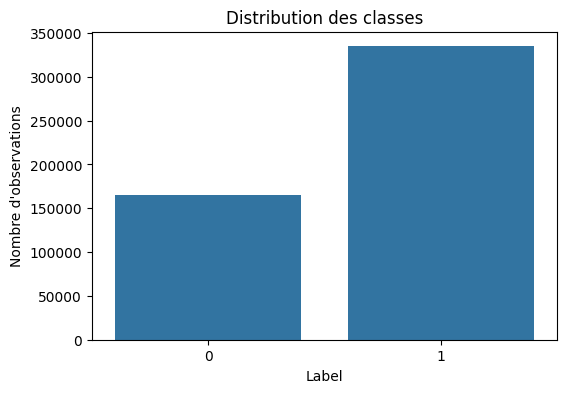

In [75]:
# Distribution de Label

label_counts = df["Label"].value_counts().sort_index()

print(label_counts)

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Label")

plt.title("Distribution des classes")

plt.xlabel("Label")

plt.ylabel("Nombre d'observations")

plt.savefig(
    "figures/Distribution de Label.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Types d'attaques

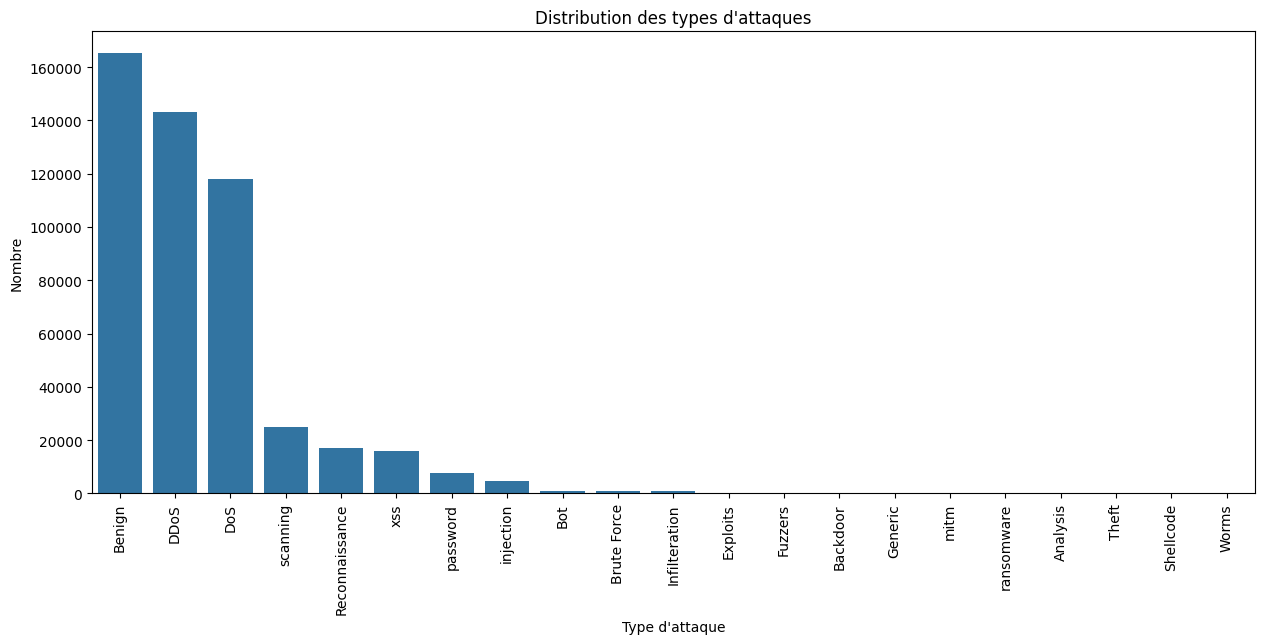

In [76]:
plt.figure(figsize=(15,6))

attack_counts = df["Attack"].value_counts()

sns.barplot(
    x=attack_counts.index,
    y=attack_counts.values
)

plt.xticks(rotation=90)

plt.title("Distribution des types d'attaques")

plt.xlabel("Type d'attaque")

plt.ylabel("Nombre")

plt.savefig(
    "figures/Distribution des types d'attaques.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Origine des données

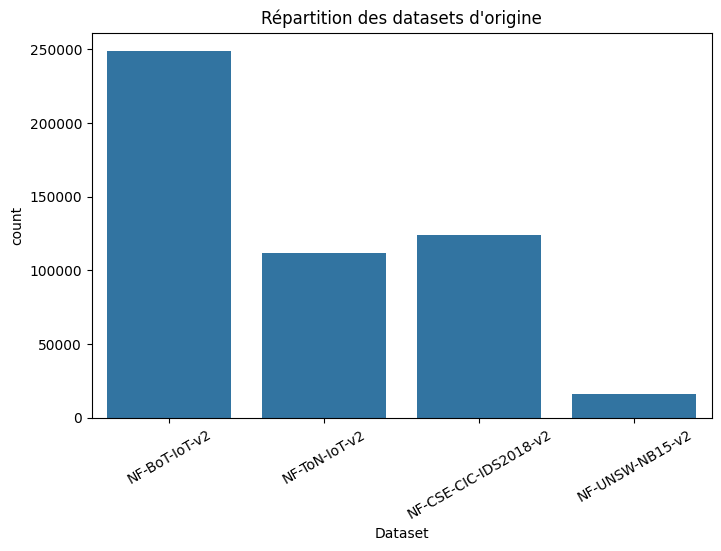

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Dataset")

plt.xticks(rotation=30)

plt.title("Répartition des datasets d'origine")

plt.savefig(
    "figures/Répartition des datasets d'origine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Corrélation

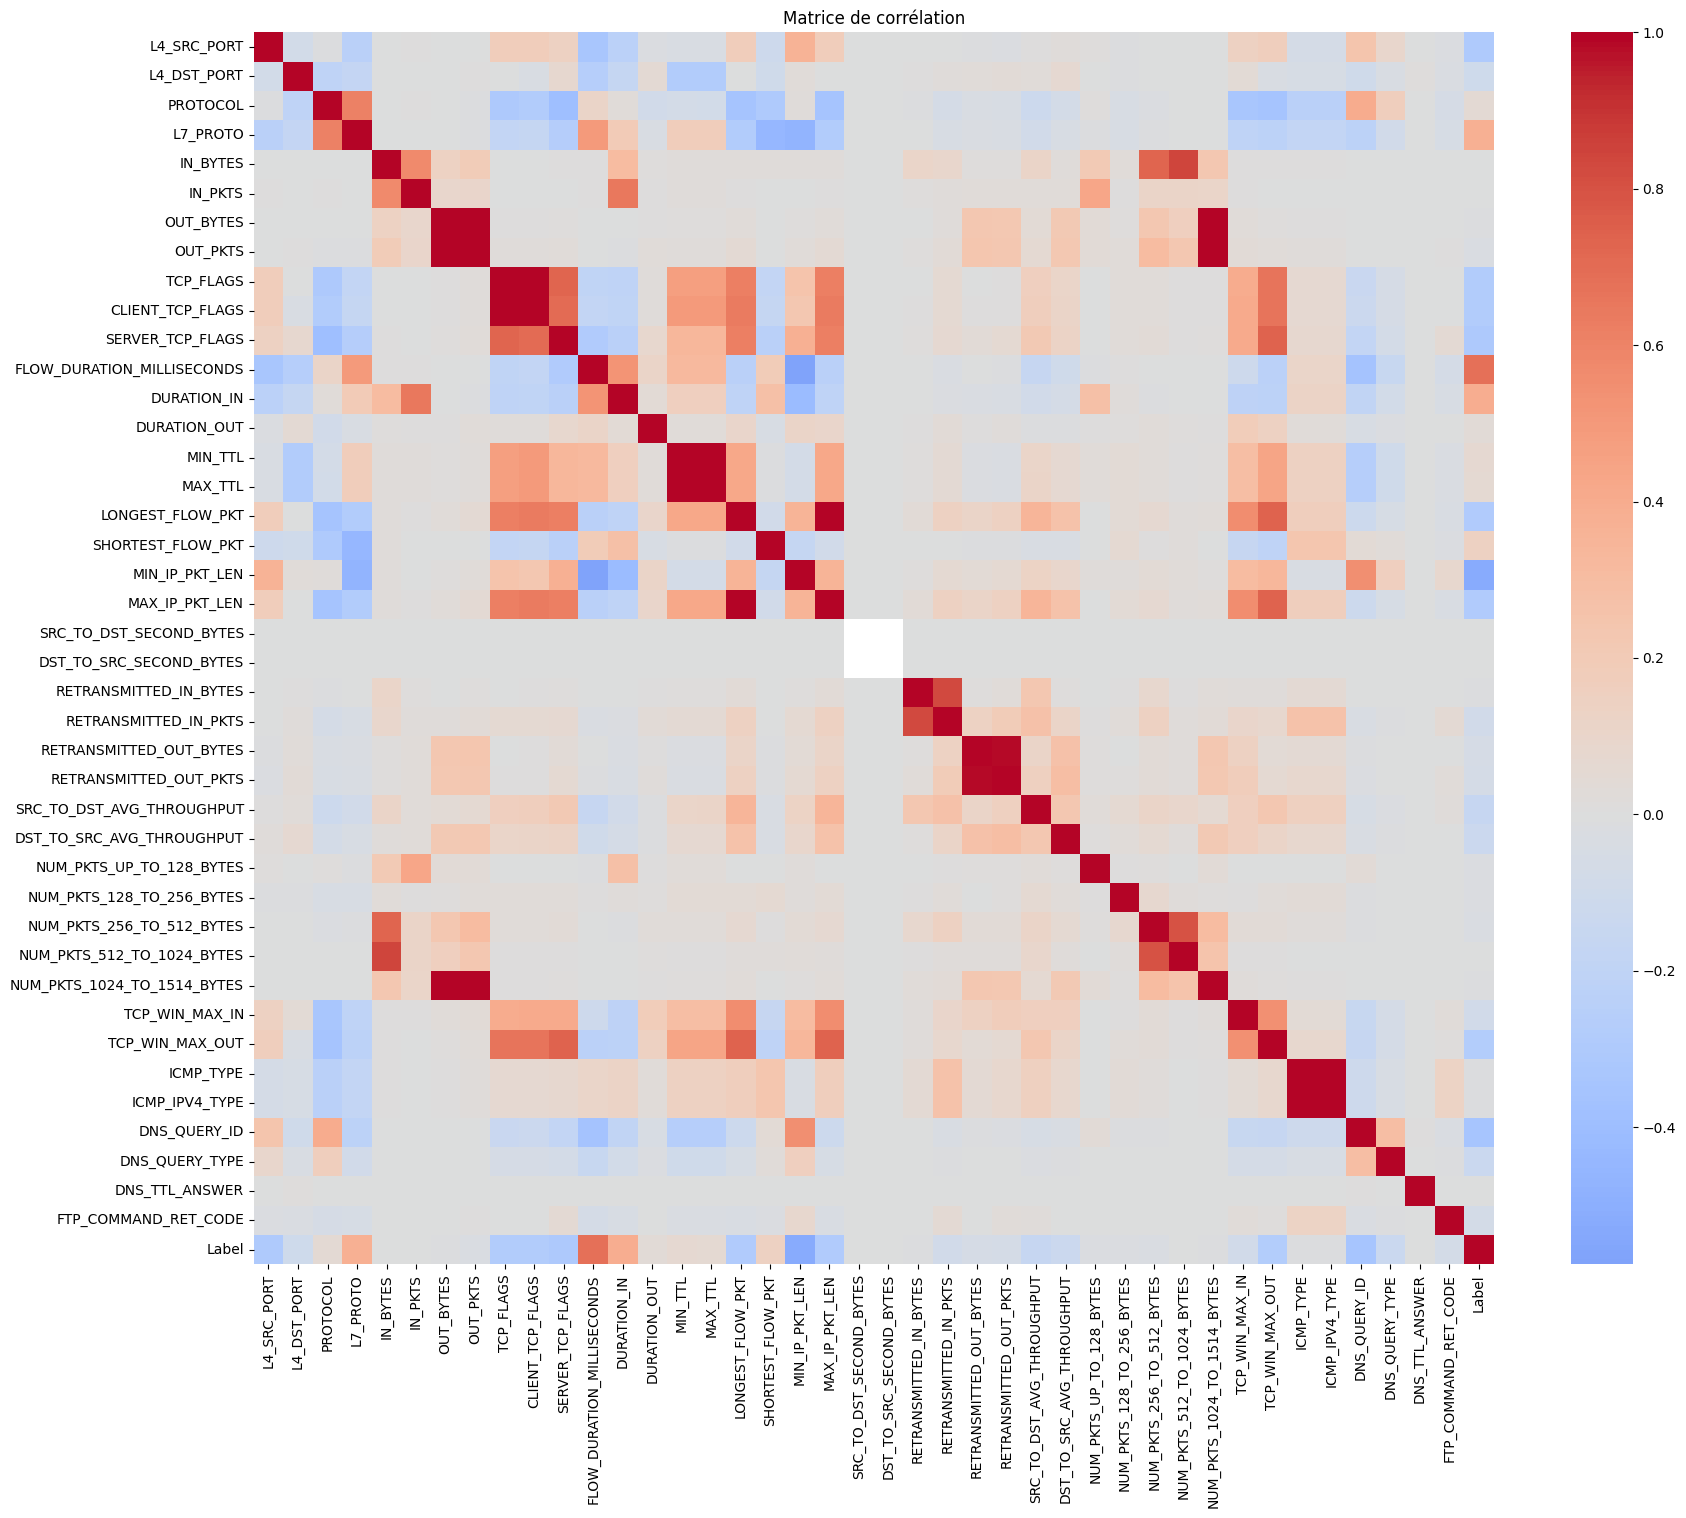

In [78]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

plt.figure(figsize=(20,16))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation")

plt.savefig(
    "figures/Matrice de corrélation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Distribution des variables

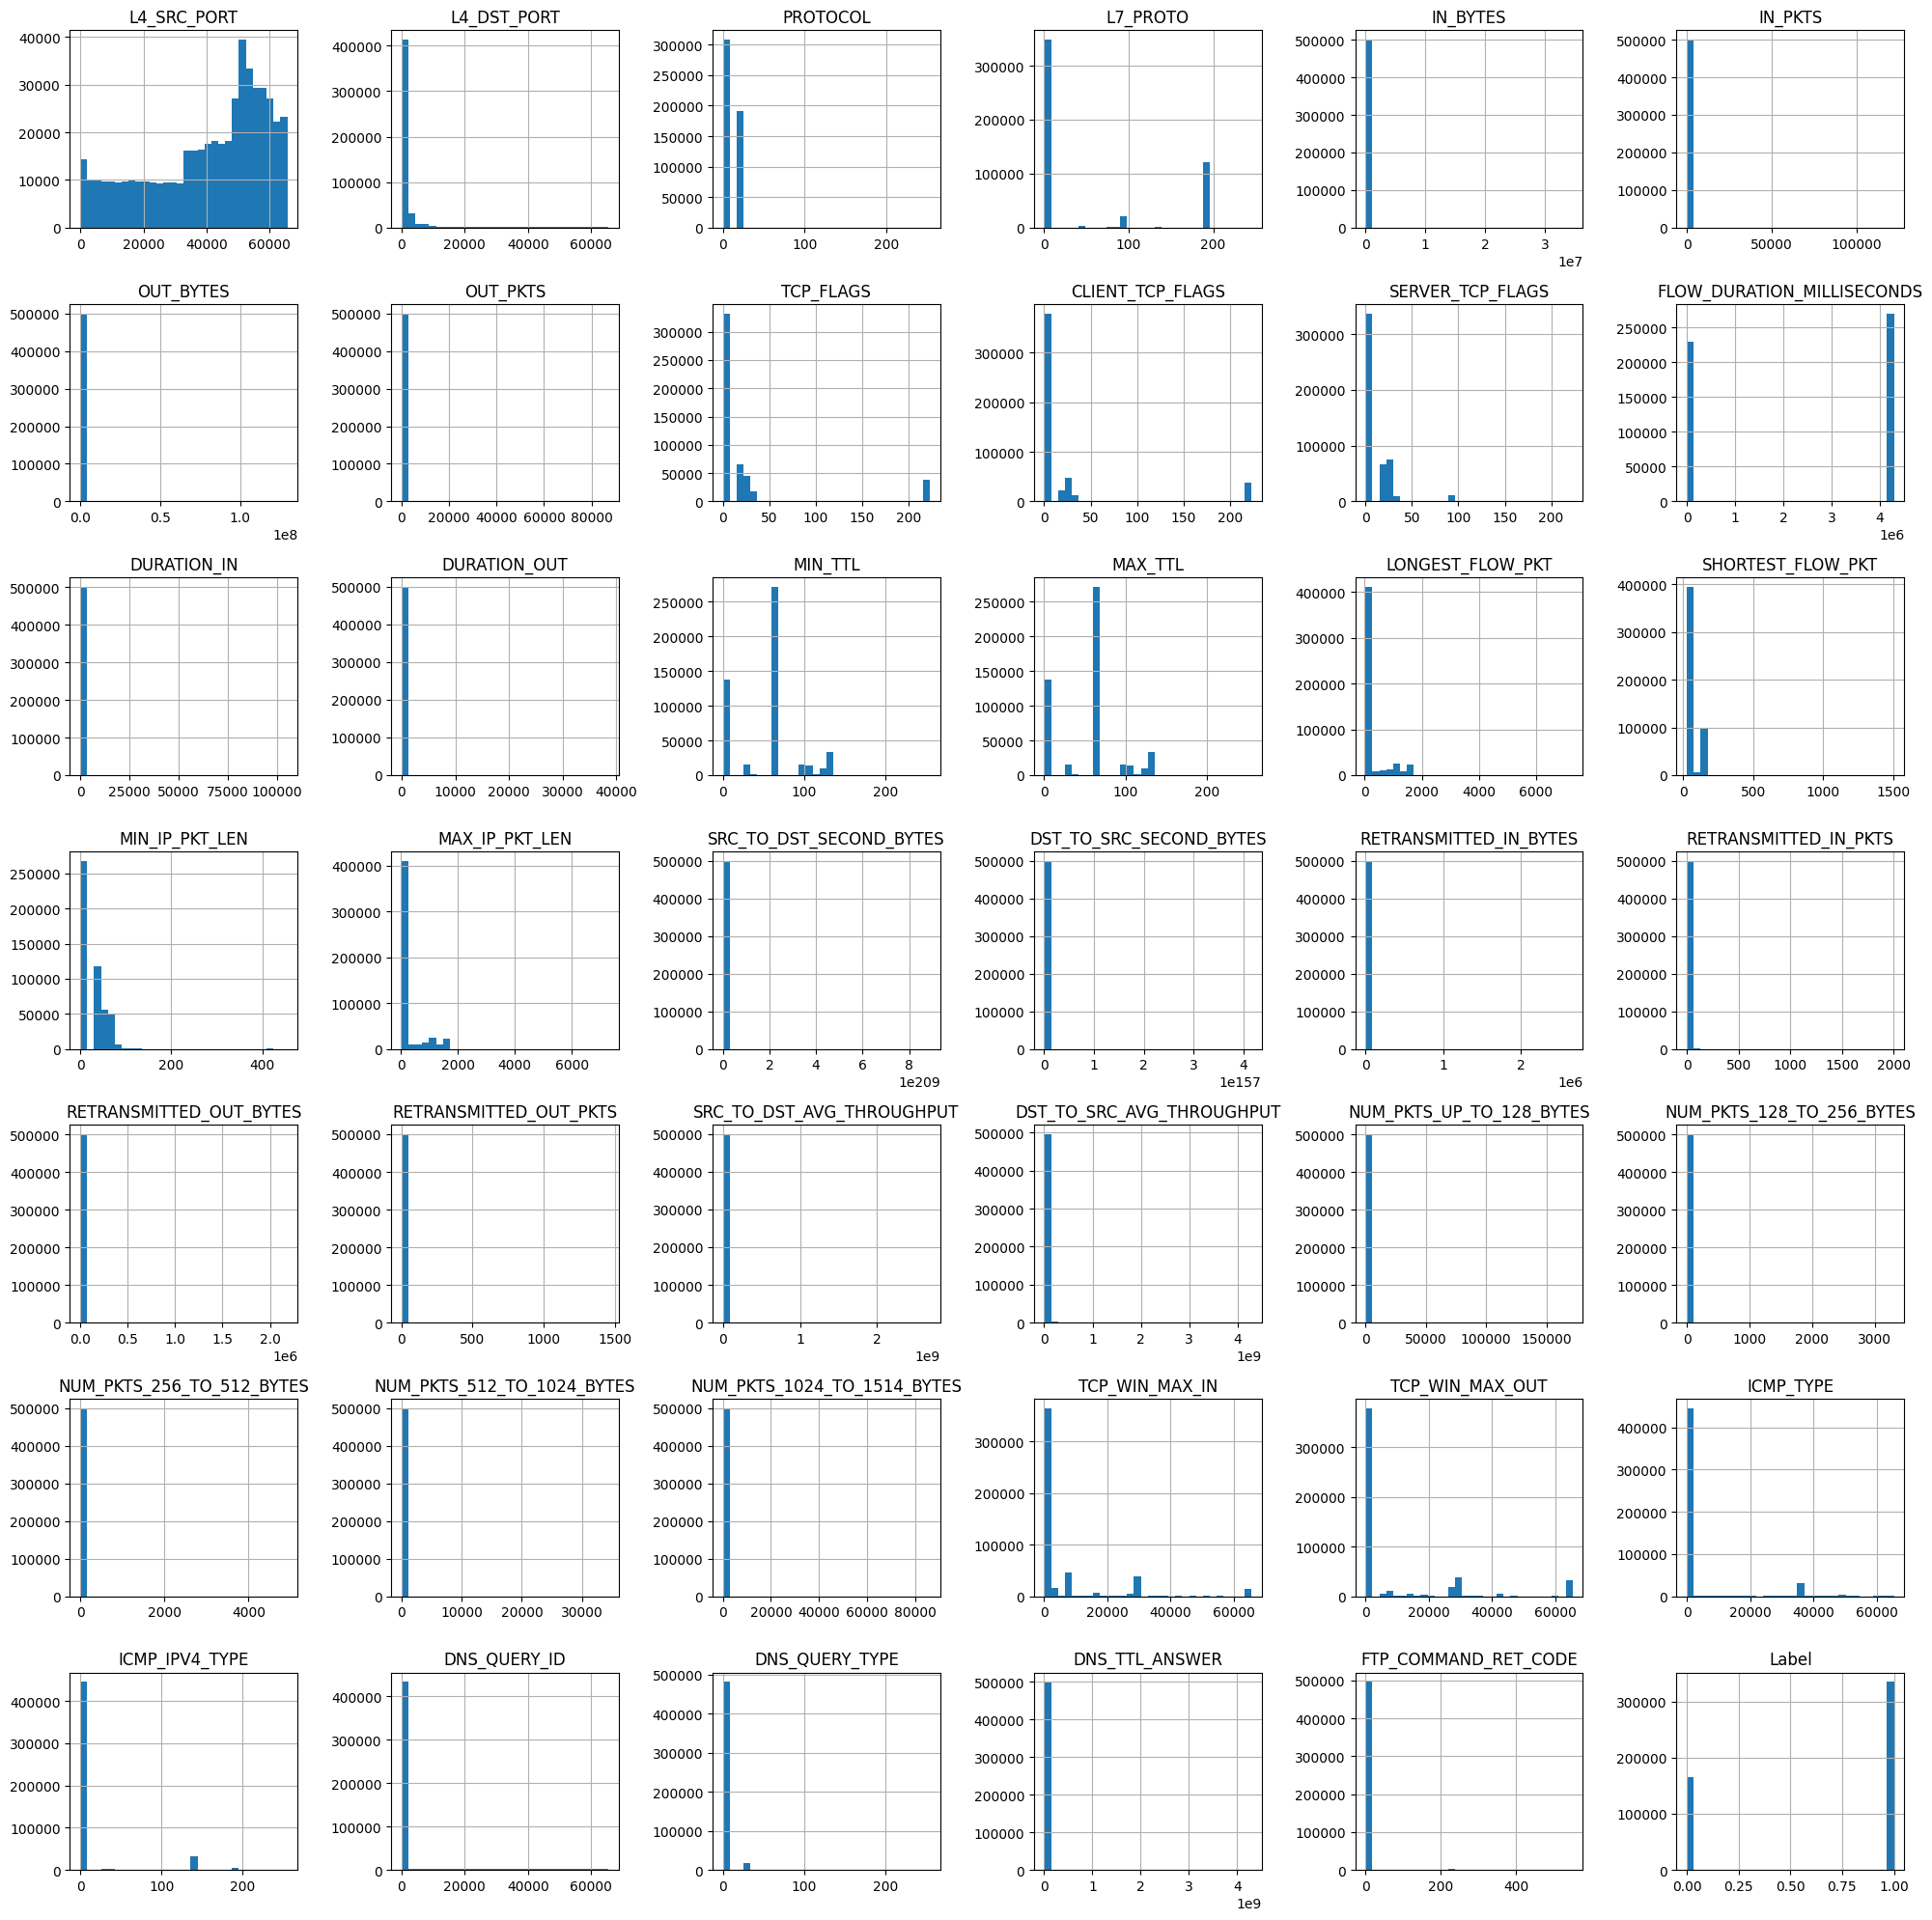

In [79]:
numeric_df.hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()

plt.show()

# Phase 2 : Prétraitement ----------------------------------------------------

# Suppression des colonnes inutiles

In [80]:
# ==========================================
# Suppression des colonnes non pertinentes
# ==========================================

columns_to_drop = [
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "Dataset",
    "Attack"
]

df = df.drop(columns=columns_to_drop)

print("Dimensions du dataset :", df.shape)

df.head()

Dimensions du dataset : (500000, 42)


,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label
0,65389,80,6,7.0,420,3,0,0,2,2,...,0,512,0,35840,140,0,0,0,0.0,1
1,11154,80,6,7.0,280,2,40,1,22,2,...,0,512,0,0,0,0,0,0,0.0,1
2,42062,1041,6,0.0,44,1,40,1,22,2,...,0,1024,0,0,0,0,0,0,0.0,0
3,46849,9110,6,0.0,44,1,40,1,22,2,...,0,1024,0,0,0,0,0,0,0.0,0
4,50360,1084,6,0.0,44,1,40,1,22,2,...,0,1024,0,0,0,0,0,0,0.0,0


# Suppression des doublons

In [81]:
# ==========================================
# Suppression des doublons
# ==========================================

print("Avant :", df.shape)

df = df.drop_duplicates()

print("Après :", df.shape)

Avant : (500000, 42)
Après : (497074, 42)


# Séparation X / y

In [82]:
# ==========================================
# Séparation des variables
# ==========================================

X = df.drop("Label", axis=1)

y = df["Label"]

print("X :", X.shape)
print("y :", y.shape)

X : (497074, 41)
y : (497074,)


# Train/Test Split

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (397659, 41)
Test : (99415, 41)


# Vérification de l'équilibre des classes

In [84]:
print("Train")

print(y_train.value_counts(normalize=True))

print()

print("Test")

print(y_test.value_counts(normalize=True))

Train
Label
1    0.66932
0    0.33068
Name: proportion, dtype: float64

Test
Label
1    0.669326
0    0.330674
Name: proportion, dtype: float64


# Importation de XGBoost

In [85]:
# ==========================================
# Importation de XGBoost
# ==========================================

from xgboost import XGBClassifier

print("XGBoost importé avec succès.")

XGBoost importé avec succès.


# Fonction d'évaluation

In [86]:
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

def evaluate_model(model, X_test, y_test):

    start = time.time()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    prediction_time = time.time() - start

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Prediction Time (s)": prediction_time
    }

    return results

# Fonction d'affichage

In [87]:
def print_results(model_name, results):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    for metric, value in results.items():
        print(f"{metric:<25} : {value:.4f}")

# Vérification des percentiles

In [88]:
X[[
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES"
]].describe(percentiles=[0.90,0.95,0.99,0.999]).T

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
SRC_TO_DST_SECOND_BYTES,497074.0,1.788421e+204,inf,0.0,1460.0,140140.0,140280.0,1.401401e+08,140280140.0,8.888889e+209
DST_TO_SRC_SECOND_BYTES,497074.0,8.369057e+151,inf,0.0,0.0,1873.0,4468.0,8.974869e+04,36091203.0,4.160041e+157


# Clipping des valeurs extrêmes

In [89]:
cols = [
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES"
]

for col in cols:

    upper = X[col].quantile(0.999)

    X[col] = X[col].clip(upper=upper)

print("Clipping terminé.")

Clipping terminé.


# Vérification

In [90]:
X[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SRC_TO_DST_SECOND_BYTES,497074.0,2.690216e+06,1.896380e+07,0.0,68.0,1460.0,4000.0,140280140.0
DST_TO_SRC_SECOND_BYTES,497074.0,8.706866e+04,1.487266e+06,0.0,0.0,0.0,164.0,36091203.0


# Refaire le Train/Test Split

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [92]:
# ==========================================
# Tableau des résultats
# ==========================================

results_df = pd.DataFrame(columns=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "MCC",
    "Training Time (s)",
    "Prediction Time (s)"
])

# Premier modèle XGBoost

In [93]:
# ==========================================
# Premier modèle XGBoost
# ==========================================

model_xgb = XGBClassifier(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss",

    tree_method="hist"

)

start = time.time()

model_xgb.fit(X_train, y_train)

training_time = time.time() - start

print(f"Temps d'entraînement : {training_time:.2f} secondes")

Temps d'entraînement : 5.31 secondes


# Évaluation

In [94]:
results_xgb = evaluate_model(model_xgb, X_test, y_test)

results_xgb["Training Time (s)"] = training_time

print_results("XGBoost", results_xgb)

XGBoost
Accuracy                  : 0.9885
Precision                 : 0.9940
Recall                    : 0.9887
F1-score                  : 0.9914
ROC-AUC                   : 0.9989
MCC                       : 0.9740
Prediction Time (s)       : 0.4506
Training Time (s)         : 5.3106


# Matrice de confusion

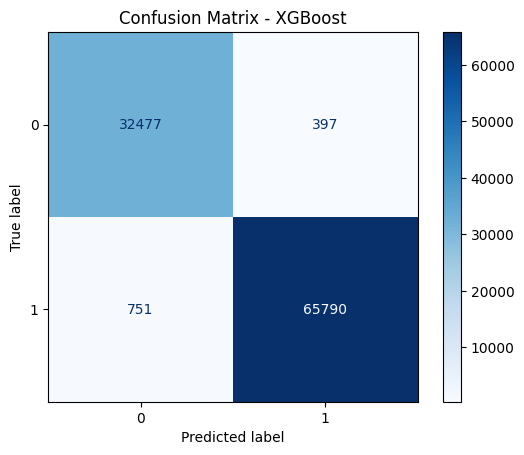

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")

plt.savefig(
    "figures/Confusion Matrix - XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Courbe ROC

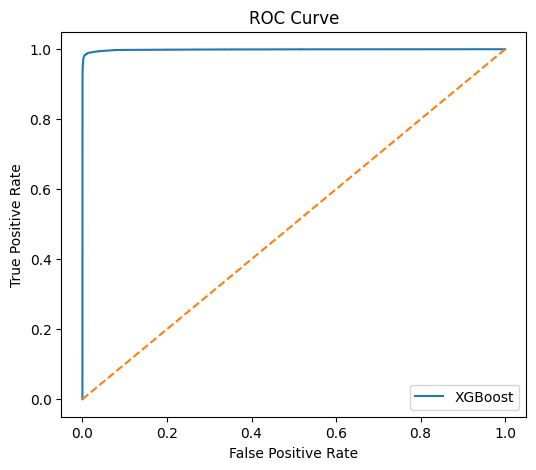

In [96]:
from sklearn.metrics import roc_curve

y_prob = model_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "figures/ROC Curve - XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sauvegarder les résultats

In [97]:
results_df = pd.DataFrame([results_xgb], index=["XGBoost"])

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC,Prediction Time (s),Training Time (s)
XGBoost,0.988452,0.994002,0.988714,0.991351,0.998892,0.974015,0.450587,5.310622


# LightGBM

# Import

In [99]:
from lightgbm import LGBMClassifier

print("LightGBM importé avec succès.")

LightGBM importé avec succès.


# Entraînement

In [100]:
# ============================
# Entraînement LightGBM
# ============================

model_lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

start = time.time()

model_lgb.fit(X_train, y_train)

training_time_lgb = time.time() - start

print(f"Temps d'entraînement : {training_time_lgb:.2f} secondes")

Temps d'entraînement : 5.99 secondes


# Évaluation

In [101]:
results_lgb = evaluate_model(
    model_lgb,
    X_test,
    y_test
)

results_lgb["Training Time (s)"] = training_time_lgb

print_results(
    "LightGBM",
    results_lgb
)

LightGBM
Accuracy                  : 0.9879
Precision                 : 0.9937
Recall                    : 0.9882
F1-score                  : 0.9909
ROC-AUC                   : 0.9989
MCC                       : 0.9728
Prediction Time (s)       : 0.9847
Training Time (s)         : 5.9890


# Confusion Matrix

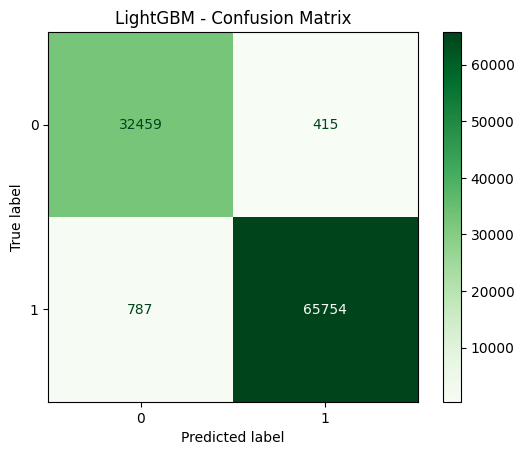

In [102]:
ConfusionMatrixDisplay.from_estimator(
    model_lgb,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("LightGBM - Confusion Matrix")

plt.savefig(
    "figures/Confusion Matrix - LightGBM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Ajouter au tableau

In [103]:
results_df.loc["LightGBM"] = results_lgb

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC,Prediction Time (s),Training Time (s)
XGBoost,0.988452,0.994002,0.988714,0.991351,0.998892,0.974015,0.450587,5.310622
LightGBM,0.987909,0.993728,0.988173,0.990943,0.998904,0.972799,0.984703,5.989009


# CatBoost

# Import

In [104]:
from catboost import CatBoostClassifier

print("CatBoost importé avec succès.")

CatBoost importé avec succès.


# Entraînement

In [105]:
# ==========================================
# CatBoost
# ==========================================

model_cat = CatBoostClassifier(

    iterations=200,
    learning_rate=0.1,
    depth=6,

    loss_function="Logloss",

    eval_metric="AUC",

    random_seed=42,

    verbose=False
)

start = time.time()

model_cat.fit(X_train, y_train)

training_time_cat = time.time() - start

print(f"Temps d'entraînement : {training_time_cat:.2f} secondes")

Temps d'entraînement : 12.17 secondes


# Évaluation

In [106]:
results_cat = evaluate_model(
    model_cat,
    X_test,
    y_test
)

results_cat["Training Time (s)"] = training_time_cat

print_results("CatBoost", results_cat)

CatBoost
Accuracy                  : 0.9850
Precision                 : 0.9912
Recall                    : 0.9863
F1-score                  : 0.9887
ROC-AUC                   : 0.9984
MCC                       : 0.9661
Prediction Time (s)       : 0.0902
Training Time (s)         : 12.1711


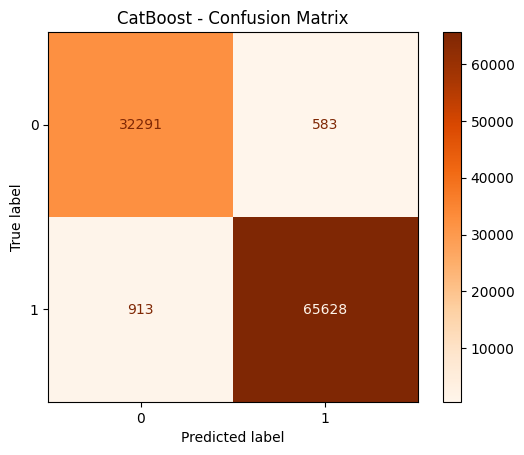

In [107]:
# Matrice de confusion

ConfusionMatrixDisplay.from_estimator(
    model_cat,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("CatBoost - Confusion Matrix")

plt.savefig(
    "figures/Confusion Matrix - CatBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Ajouter au tableau

In [108]:
results_df.loc["CatBoost"] = results_cat

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC,Prediction Time (s),Training Time (s)
XGBoost,0.988452,0.994002,0.988714,0.991351,0.998892,0.974015,0.450587,5.310622
LightGBM,0.987909,0.993728,0.988173,0.990943,0.998904,0.972799,0.984703,5.989009
CatBoost,0.984952,0.991195,0.986279,0.988731,0.998428,0.966118,0.090161,12.171146


# TabNet

In [109]:
!pip install -q pytorch-tabnet

# Standardisation

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_tab = scaler.fit_transform(X_train)
X_test_tab = scaler.transform(X_test)

# Import

In [111]:
from pytorch_tabnet.tab_model import TabNetClassifier

# Entraînement

In [112]:
import numpy as np
import time

model_tab = TabNetClassifier(
    seed=42,
    verbose=0
)

start = time.time()

model_tab.fit(
    X_train_tab,
    y_train.to_numpy(),
    max_epochs=30,
    patience=10,
    batch_size=4096,
    virtual_batch_size=512
)

training_time_tab = time.time() - start

print(f"Temps d'entraînement : {training_time_tab:.2f} s")

Temps d'entraînement : 181.24 s


# Évaluation

In [113]:
results_tab = evaluate_model(
    model_tab,
    X_test_tab,
    y_test
)

results_tab["Training Time (s)"] = training_time_tab

print_results("TabNet", results_tab)

results_df.loc["TabNet"] = results_tab

TabNet
Accuracy                  : 0.9649
Precision                 : 0.9871
Recall                    : 0.9600
F1-score                  : 0.9734
ROC-AUC                   : 0.9946
MCC                       : 0.9225
Prediction Time (s)       : 1.5052
Training Time (s)         : 181.2414


# # Ajouter au tableau

In [114]:
results_df.sort_values(
    by="F1-score",
    ascending=False
)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC,Prediction Time (s),Training Time (s)
XGBoost,0.988452,0.994002,0.988714,0.991351,0.998892,0.974015,0.450587,5.310622
LightGBM,0.987909,0.993728,0.988173,0.990943,0.998904,0.972799,0.984703,5.989009
CatBoost,0.984952,0.991195,0.986279,0.988731,0.998428,0.966118,0.090161,12.171146
TabNet,0.964875,0.987128,0.960040,0.973396,0.994569,0.922521,1.505169,181.241352


# Exporter les résultats

In [115]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [116]:
results_df.to_csv("results/model_comparison.csv")

# Confusion Matrix

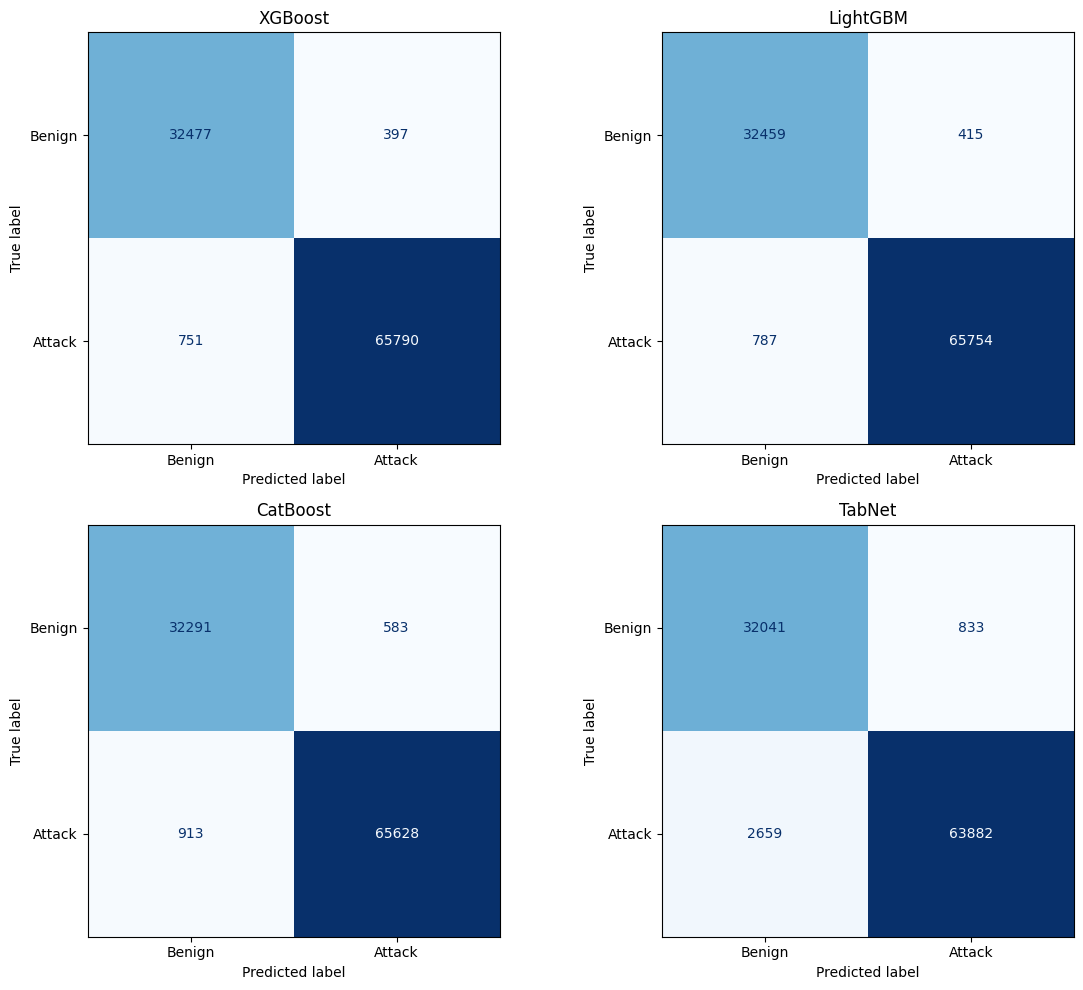

<class 'xgboost.sklearn.XGBClassifier'>
<class 'lightgbm.sklearn.LGBMClassifier'>
<class 'catboost.core.CatBoostClassifier'>
<class 'pytorch_tabnet.tab_model.TabNetClassifier'>


In [117]:
import os
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ("XGBoost", model_xgb, X_test),
    ("LightGBM", model_lgb, X_test),
    ("CatBoost", model_cat, X_test),
    ("TabNet", model_tab, X_test_tab)
]

for ax, (name, model, X_eval) in zip(axes.ravel(), models):

    # Prédictions
    y_pred = model.predict(X_eval)

    # Pour TabNet, on convertit en entier si nécessaire
    y_pred = y_pred.astype(int)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(name, fontsize=12)

plt.tight_layout()

plt.savefig(
    "figures/confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(type(model_xgb))
print(type(model_lgb))
print(type(model_cat))
print(type(model_tab))

# Comparer les 4 modèles sur une seule figure ROC

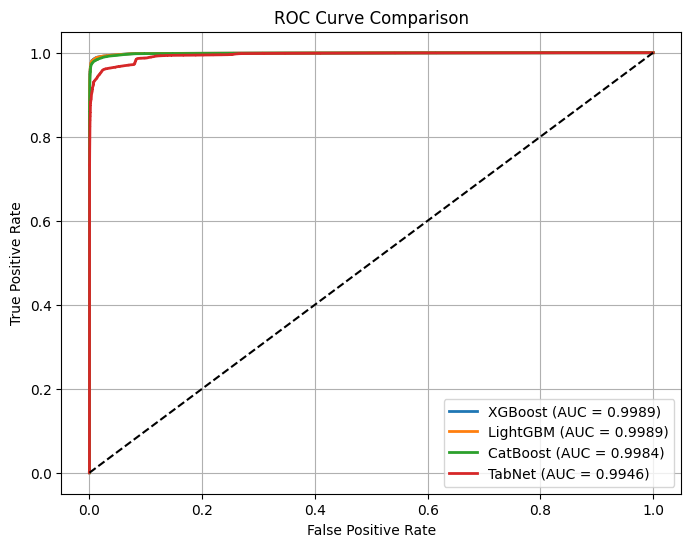

In [118]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "XGBoost": (model_xgb, X_test),
    "LightGBM": (model_lgb, X_test),
    "CatBoost": (model_cat, X_test),
    "TabNet": (model_tab, X_test_tab)
}

for name, (model, X_eval) in models.items():

    y_prob = model.predict_proba(X_eval)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.savefig(
    "figures/ROC Curve Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Comparaison des courbes Precision-Recall

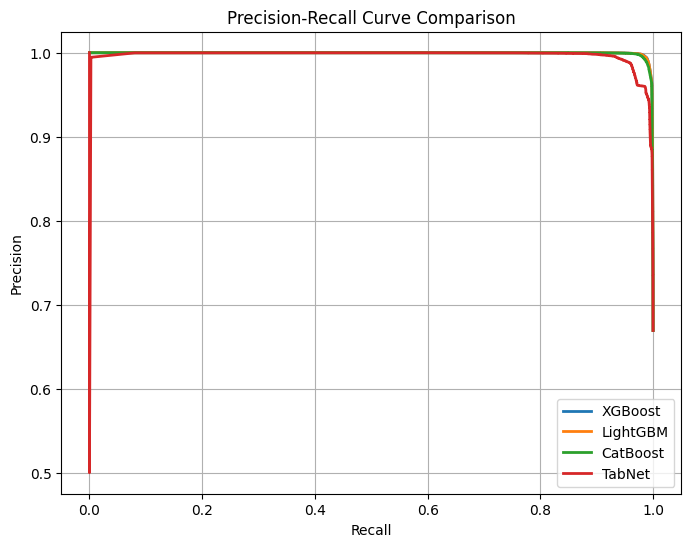

In [119]:
plt.figure(figsize=(8,6))

for name, (model, X_eval) in models.items():

    y_prob = model.predict_proba(X_eval)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, lw=2, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.savefig(
    "figures/pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP sur XGBoost

In [120]:
!pip install -q shap

In [121]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = explainer.shap_values(X_test)

# Feature Importance SHAP

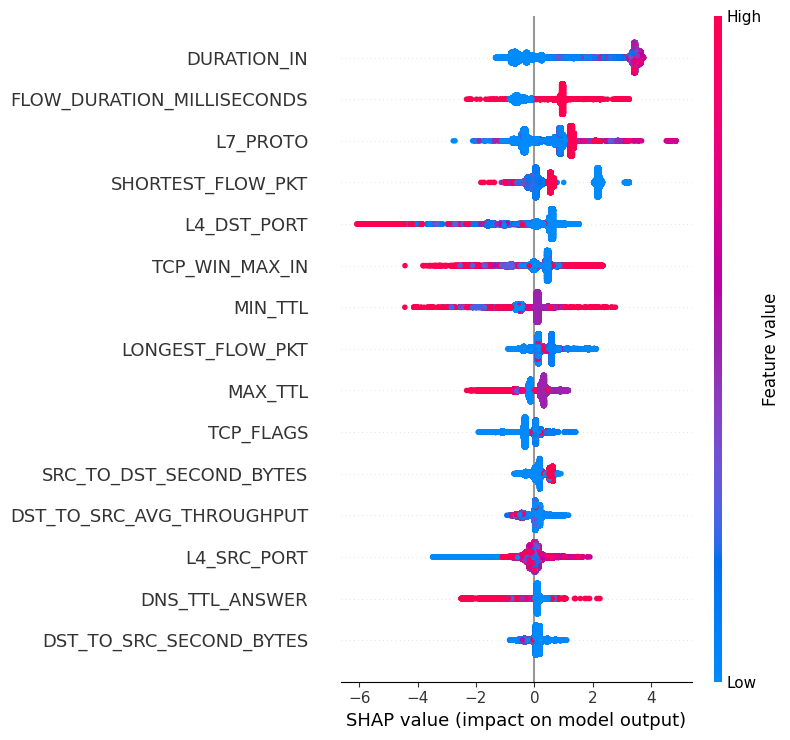

In [122]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_summary(vf).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bar Plot SHAP

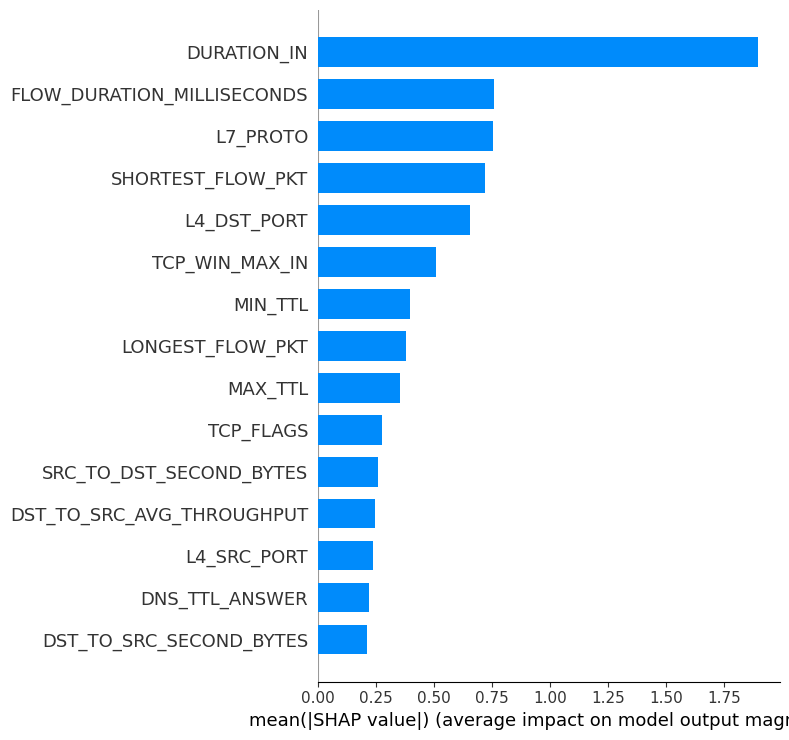

In [123]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_bar(vf).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sauvegarder les résultats

In [124]:
results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC,Prediction Time (s),Training Time (s)
XGBoost,0.988452,0.994002,0.988714,0.991351,0.998892,0.974015,0.450587,5.310622
LightGBM,0.987909,0.993728,0.988173,0.990943,0.998904,0.972799,0.984703,5.989009
CatBoost,0.984952,0.991195,0.986279,0.988731,0.998428,0.966118,0.090161,12.171146
TabNet,0.964875,0.987128,0.960040,0.973396,0.994569,0.922521,1.505169,181.241352


In [125]:
results_df.to_csv(
    "model_comparison.csv",
    index=True
)

# Optimiser XGBoost avec Optuna

In [126]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Fonction objectif

In [127]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist"
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1"
    ).mean()

    return score

# Sauvegarder le meilleur modèle

In [130]:
import joblib

joblib.dump(
    model_xgb,
    "best_xgboost_model.pkl"
)

['best_xgboost_model.pkl']